In [1]:
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import pickle

import sys
sys.path.append("/mnt/aridata1/users/ariasant/MW-sbi")

# Convert infall times from Gyr to redshift
import astropy.units as u
from astropy.cosmology import Planck15, z_at_value
import codes.plotting_utils as plots
import codes.calibration_model as cm
from scipy.stats import binned_statistic


output_dir = "/mnt/aridata1/users/ariasant/MW-sbi/out2/"
posterior_samples_dir = "/mnt/aridata1/users/ariasant/MW-sbi/out/"

features = ['E', 'L', 'FeH', 'MgFe']

plots.call_plotting_formatting()


# Define markers for the different substructures
substructures = [
        'GES', 
        'Sagittarius', 
        'Helmi',
        'Sequoia_K19',
        'Sequoia_M19',
        'Sequoia_N20',
        'Iitoi', 
        'Thamnos',
        'LMS', 
        'Heracles', 
    ]

substructure_labels = {
    'Arjuna': 'Arjuna',
    'GES': 'GES',
    'Sagittarius': 'Sagittarius',
    'Helmi': 'Helmi streams',
    'Sequoia_K19': 'K19',
    'Sequoia_M19': 'M19',
    'Sequoia_N20': 'N20',
    'Iitoi': "I'itoi",
    'Thamnos': "Thamnos",
    'LMS': "LMS-1/Wukong",
    'Heracles': "Heracles"
}

substructure_markers = dict(zip(substructures, plots.generate_markers(len(substructures))))

# No Aleph: because it might be a spurious detection (linked to the high-alpha disk)
# No Arjuna: because it significantly overlaps chemically with GES
# No Nyx: because it significantly overlaps chemically with the high-alpha disk
# Order substructure list alphabetically
substructures = sorted(substructures)
# Associate a color to each substructure
colors = cc.glasbey_light[:len(substructures)]
colors_dict = dict(zip(substructures,colors))

#########################################################################################
#########################################################################################
#
#               DATASET
#
#########################################################################################
#########################################################################################


# LOAD DATA
df = pd.read_pickle("/mnt/aridata1/users/ariasant/MW-sbi/data/apogee_substructures_ds.pkl")
df.dropna(inplace=True, subset=["FeH","MgFe","E","L"])


obs_data = pd.read_pickle("/mnt/aridata1/users/ariasant/MW-sbi/data/apogee_substructures_ds.pkl")

obs_data.dropna(subset=features, inplace=True)
obs_data = obs_data[(obs_data["E"]<0)&(obs_data["L"]>0)]
obs_data["E"] = np.log(-obs_data["E"].values)
obs_data["L"] = np.log(obs_data["L"].values)

# Select accreted stars
obs_accreted = ((obs_data.AlFe<-0.07) & (obs_data.MgMn>=0.25)) | \
               ((obs_data.AlFe>=-0.07) & (obs_data.MgMn>=4.25*obs_data.AlFe+0.5475))
obs_accreted = np.logical_or.reduce([obs_accreted]+[obs_data[f"{substructure}_flag"]==1 
                                    for substructure in substructures])

### Chemo-dynamical properties of MW accreted stars

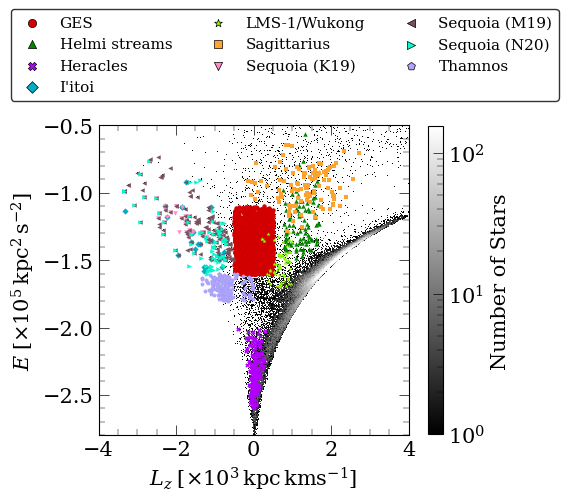

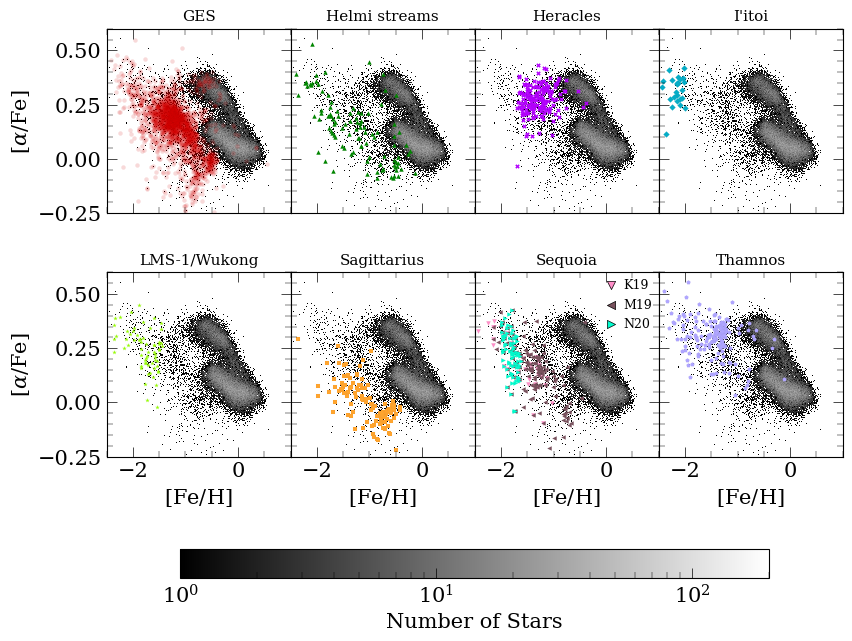

In [2]:
# Plot IoM 
LMAX = 4
EMIN = -2.8

fig_IoM,ax_IoM = plots.plot_2D_heatmap(
    x=df['Lz']*1e-3,
    y=df['E']*1e-5,
    xlabel="$L_{z} \; [\\times10^{3} \, \mathrm{kpc}\, \mathrm{kms}^{-1}]$",
    ylabel="$E \; [\\times10^{5} \, \mathrm{kpc}^{2}\, \mathrm{s}^{-2}]$",
    filename="/mnt/aridata1/users/ariasant/MW-sbi/data/IoM",
    extent=[[-LMAX,LMAX],[EMIN,-0.5]],
    cmap="gist_gray",
    return_figure=True
)

fig_IoM.set_figheight(5)
fig_IoM.set_figwidth(5)

# Fix the axis limits after plotting the heatmaps
ax_IoM.set_xlim([-LMAX, LMAX])
ax_IoM.set_ylim([EMIN, -0.5])


for substructure in substructures:
    # Load position of stars 
    substructure_flag = f"{substructure}_flag"
    df_sub = df[df[substructure_flag]==1]
    
    if substructure=="GES":
        alpha=0.15
    elif substructure=="Arjuna":
        continue
    else:
        alpha=0.5
    
    if "Sequoia" in substructure:
        label = f"Sequoia ({substructure_labels[substructure]})"
    else:
        label = substructure_labels[substructure]

    # Plot points on top of IoM figure
    ax_IoM.scatter(
        x=df_sub['Lz']*1e-3,
        y=df_sub['E']*1e-5, 
        s=10,
        marker=substructure_markers[substructure],
        edgecolor="k",
        linewidth=0.01,
        color=colors_dict[substructure]
    )
    
    ax_IoM.scatter(
        [],[], 
        s=35,
        marker=substructure_markers[substructure],
        edgecolor="k",
        linewidth=0.5,
        color=colors_dict[substructure],
        label=label
    )
    
    
# Plot legend outside of figure
ax_IoM.legend(
    loc="upper center", 
    bbox_to_anchor=(0.6, 1.4), 
    ncols=3,
    frameon=True, edgecolor='black',
    fontsize=11
)

fig_IoM.savefig(f"{output_dir}IoM.pdf",dpi=300)

# ALPHA-IRON PLANE
xlim = [-2.5,1]
ylim = [-0.25,0.6]

fig,axs = plt.subplots(
    ncols=4, 
    nrows=2, 
    gridspec_kw={"wspace":0, 
                "hspace":0.3, 
                "width_ratios": [1,1,1,1],
                "height_ratios": [1,1]},
    sharey=True,
    sharex=True,
    figsize=(9.5,8)
)

axs  = axs.flatten()
i=0

for substructure in substructures:

    if substructure=="Arjuna":
        continue
    
    substructure_flag = f"{substructure}_flag"
    df_sub = df[df[substructure_flag]==1]
    
    ax_chem=axs[i]
    plot = plots.plot_ax(x=df['FeH'],
            y=df['MgFe'],
            ax=ax_chem,
            extent=[xlim, ylim],
            cmap="gist_gray")
    
    if substructure=="GES":
        alpha=0.15
    else:
        alpha=1
    
    ax_chem.scatter(
        x=df_sub['FeH'],
        y=df_sub['MgFe'], 
        s=10,
        marker=substructure_markers[substructure],
        color=colors_dict[substructure],
        edgecolor='k',
        linewidth=0.01,
        alpha=alpha)
    ax_chem.scatter(
        [],[], 
        s=35,
        marker=substructure_markers[substructure],
        edgecolor="k",
        linewidth=0.5,
        color=colors_dict[substructure],
        label=substructure_labels[substructure]
    )
    
    ax_chem.set_xlim(xlim)
    ax_chem.set_ylim(ylim)
    ax_chem.set_aspect((xlim[1]-xlim[0])/(ylim[1]-ylim[0]))
    
    ax_chem.set_title(substructure_labels[substructure], fontsize=11)
    
    if i%4==0:
        ax_chem.set_ylabel("$[\\alpha/\mathrm{Fe}]$")
    if i//4==1:
        ax_chem.set_xlabel("$[\mathrm{Fe}/\mathrm{H}]$")
    
    
    if substructure not in ['Sequoia_K19','Sequoia_M19']:
        i+=1
        
    if substructure=="Sequoia_N20":
        ax_chem.legend(
            loc="upper right",
            fontsize=9,
            handletextpad=0,
            borderpad=0,
            frameon=False
        )
        ax_chem.set_title("Sequoia", fontsize=11)
        
#axs[-1].set_visible(False)


cbar = fig.colorbar(plot, ax=axs.ravel().tolist(), shrink=0.8, orientation="horizontal")
cbar.set_label('Number of Stars')

fig.savefig(f"{output_dir}alphaIron.pdf", dpi=300)

### Comparison between SBI predictions and literature 

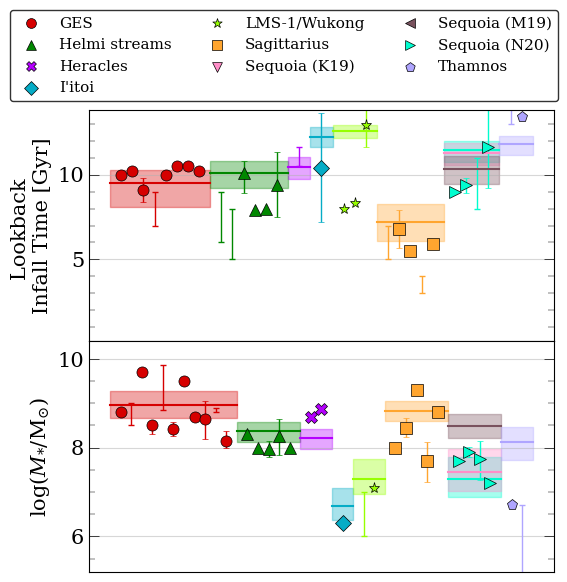

In [3]:
# Merger parameter predictions from the literature

infall_times = {
    "GES": [ 10, (10.2,0.2,0.1), (9.1,0.7,0.7), (7,9), 10, 10.5, 10.5, (10.2,0.2,0.2)],
    "Helmi": [(6,9), (5,8), (10.1,0.7,1.2), 7.9, 8, (9.4,1.9,1.9)],
    "Heracles": [(10.5,11.6)],
    "Iitoi": [(10.4,3.2,3.2)],
    "LMS": [8, 8.3, (12.9,1.3,1.3)],
    "Sagittarius": [(5,7), (6.8,1.1,1.1), 5.5, (3,4), 5.9,],
    "Sequoia_K19": [9, (9.4,0.4,0.5), (8,11), (11.6,2.4,2.4)],
    "Sequoia_M19": [9, (9.4,0.4,0.5), (8,11), (11.6,2.4,2.4)],
    "Sequoia_N20": [9, (9.4,0.4,0.5), (8,11), (11.6,2.4,2.4)],
    "Thamnos": [(13,14), 13.4]
}

stellar_masses = {
    "GES": [8.8, (8.5,9), 9.7, (8.5,0.1,0.2), (8.85,9.85), (8.43,0.15,0.16), 9.5, 8.7, (8.64,0.4,0.44), (8.8,8.9), (8.16,0.21,0.17)],
    "Helmi": [8.3, 8, (7.96,0.19,0.18), (8.26, 0.38, 0.42), 8],
    "Heracles": [8.7, 8.86],
    "Iitoi": [6.3],
    "LMS": [(6,7), 7.1],
    "Sagittarius": [8,  (8.44,0.22,0.21), 9.3, (7.69, 0.43, 0.47), 8.8],
    "Sequoia_K19": [7.7, (7.9,0.11,0.11), (7.74, 0.42, 0.46), 7.2],
    "Sequoia_M19": [7.7, (7.9,0.11,0.11), (7.74, 0.42, 0.46), 7.2],
    "Sequoia_N20": [7.7, (7.9,0.11,0.11), (7.74, 0.42, 0.46), 7.2],
    "Thamnos": [6.7, (5,6.7)]
}


fig, axs = plt.subplots(2, 1, 
                        figsize=(6,6),
                       gridspec_kw={"hspace":0})


axs[0].set_ylim([0.2, 13.8])
#ax.set_xlim([0, 34])

axs[0].set_ylabel("Lookback \nInfall Time [Gyr]")
axs[0].set_xticks([])
axs[0].grid(alpha=0.5)

axs[1].set_ylabel("$\log(M_{*}/\mathrm{M}_{\odot})$")
axs[1].set_ylim([5.2,10.4])
axs[1].set_xticks([])
axs[1].grid(alpha=0.5)

def plot_comparison_with_literature(ax,
                                    ind_samples,
                                    substructures, 
                                    literature_dict):
                                    
    n = 0
                                    
    for substructure in substructures:
        # Get estimate of infall time from GalactiKit
        samples = pickle.load(open(f"{posterior_samples_dir}{substructure}.pkl", "rb"))

        median = np.percentile(samples[:, ind_samples], 50)
        _16 = np.percentile(samples[:, ind_samples], 16)
        _84 = np.percentile(samples[:, ind_samples], 84)
    

        if substructure in ["Sequoia_K19", "Sequoia_M19", "Arjuna"]:
                continue

        start = n
        
        if substructure in literature_dict.keys():
            for estimate in literature_dict[substructure]:
                if isinstance(estimate, tuple): 
                    if len(estimate)==2:
                        ax.errorbar(n, [estimate[0]], yerr=[[0], [estimate[1]-estimate[0]]],
                                    fmt='none', 
                                    color=colors_dict[substructure],
                                    capsize=2,
                                    linewidth=1)
                    else:
                        ax.errorbar(n, [estimate[0]], 
                                    yerr=[[estimate[2]], [estimate[1]]],
                                    marker=substructure_markers[substructure],
                                    markersize=8,
                                    markeredgecolor='k',
                                    markeredgewidth=0.5,
                                    color=colors_dict[substructure],
                                    capsize=2,
                                    linewidth=1)

                else:
                    ax.errorbar(n, 
                               estimate, 
                                [[1e-3],[1e-3]],
                               color=colors_dict[substructure],
                               marker=substructure_markers[substructure],
                               markersize=8,
                               markeredgecolor='k',
                               markeredgewidth=0.5,
                              )

                n += 1

        x = list(range(start-1, n+1))  # Ensure correct range


        ax.fill_between(x,
                        [_16] * len(x),  # Use list comprehension
                        [_84] * len(x),
                        color=colors_dict[substructure],
                        alpha=0.35)
        ax.plot(x,
                [median] * len(x),
                color=colors_dict[substructure])
        
        n+=1
        if substructure == "Sequoia_N20":

            for s in ["Sequoia_K19", "Sequoia_M19"]:

                samples = pickle.load(open(f"{posterior_samples_dir}{s}.pkl", "rb"))
                median = np.percentile(samples[:, ind_samples], 50)
                _16 = np.percentile(samples[:, ind_samples], 16)
                _84 = np.percentile(samples[:, ind_samples], 84)
                ax.fill_between(x,
                            [_16] * len(x),  # Use list comprehension
                            [_84] * len(x),
                            color=colors_dict[s],
                            alpha=0.35)
                ax.plot(x,
                        [median] * len(x),
                        color=colors_dict[s])


    return
            
plot_comparison_with_literature(ax=axs[0],
                               ind_samples=0,
                               substructures=substructures,
                               literature_dict=infall_times)


plot_comparison_with_literature(ax=axs[1],
                               ind_samples=1,
                               substructures=substructures,
                               literature_dict=stellar_masses)

handles = []
for substructure, color in colors_dict.items():
    if substructure=="Arjuna":
        continue
    if "Sequoia" in substructure:
        label = f"Sequoia ({substructure_labels[substructure]})"
    else:
        label = substructure_labels[substructure]
        
    line = plt.scatter([],[], 
                   s=50,
                   marker=substructure_markers[substructure],
                   edgecolor="k",
                   linewidth=0.5,
                   color=colors_dict[substructure],
                   label=label) 
    handles.append(line)


fig.legend(handles=handles,
           loc="upper center", 
           bbox_to_anchor=(0.45, 1.06), 
           ncols=3, 
           frameon=True, 
           edgecolor='black', 
           fontsize=11)

fig.savefig(f"{output_dir}Comparison_with_literature.pdf", dpi=200)


### Predicted MW progenitors MZR and satellites in the Auriga simulations

/mnt/aridata1/users/ariasant/environments/fish/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sampling: [chol, mu_E, mu_FeH, mu_L, mu_MgFe, noise]
/tmp/ipykernel_3451102/555401340.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from t

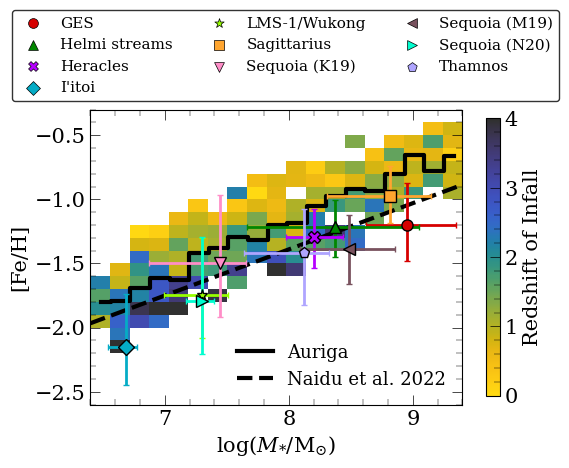

In [4]:
noise_model = cm.generate_mean_cov_model(
    features=["E","L","FeH","MgFe"],
    n_stars_per_prog=100
)
noise_list = cm.sample_noise_training(
    model=noise_model,
    n_samples=10000,
    random_seed=16
)

from scipy.stats import binned_statistic

sim_data = pd.read_pickle("/mnt/aridata1/users/ariasant/MW-sbi/trials2/data/sim_ds_processed_Suite_ELFeHMgFe.pkl")

# Bin by stellar mass
n_bins = 20
bins = np.logspace(6.4, 9.4, n_bins)
log_Mstar = sim_data.groupby("progID")["log_Mprog_stellar"].median()
t_infall = sim_data.groupby("progID")["infall_time"].median()

def fn(group):
    idx = np.random.randint(10000)
    FeH_noise = noise_list[idx,:,2]
    group_FeH = group["FeH"].values

    augmented_array = []
    for i in range(100):
        augmented_array.append(group_FeH+np.random.choice(FeH_noise, len(group)))

    return np.median(np.hstack(augmented_array))

FeH_median = sim_data.groupby("progID").apply(fn)

medians, edges, _ = binned_statistic(10**log_Mstar, FeH_median, statistic="median", bins=bins)

p16, edges, _ = binned_statistic(10**log_Mstar, FeH_median, statistic=lambda x: np.percentile(x,5), bins=bins)
p84, edges, binnumber = binned_statistic(10**log_Mstar, FeH_median, statistic=lambda x: np.percentile(x,95), bins=bins)

bin_centres = np.log10((edges[1:]+edges[:-1])*0.5)

import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.cosmology import Planck15
from astropy import units as u
from astropy.cosmology import z_at_value


fig, ax = plt.subplots(figsize=(6, 6))

# Plot the median line
ax.step(bin_centres, medians, c="k", lw=3, label="Auriga", where='mid')

# Setup colormap
# 1. Get the standard Blues colormap
# (Use plt.cm.Blues if cm.get_cmap is deprecated in your version)
cmap_orig = cc.cm.CET_L20_r#plt.cm.cividis_r#plt.cm.binary

# 2. Sample colors starting from 0.3 (skipping the white 0.0-0.3 range)
#    to 1.0 (darkest blue)
colors_no_white = cmap_orig(np.linspace(0.1, 1.0, 256))

# 3. Create a new custom colormap
cmap = mpl.colors.LinearSegmentedColormap.from_list("Blues_No_White", colors_no_white)
norm = mpl.colors.Normalize(vmin=0, vmax=4) # Adjusted range for Redshift likely 0-4
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

# Loop over Mass Bins
for i in range(len(medians)):
    # FIX 1: binned_statistic returns indices starting at 1
    # We filter data that is within the mass bin AND within the 16-84th FeH percentile
    mask = (binnumber == i + 1) & (FeH_median >= p16[i]) & (FeH_median <= p84[i])
    
    # Skip if no stars found in this region
    if np.sum(mask) == 0:
        continue

    # Extract data for this mass bin
    local_FeH = FeH_median[mask]
    local_t_infall = t_infall[mask]
    
    # FIX 4: Safer dynamic binning. 
    # Create 10 sub-bins specifically spanning the p16-p84 range of THIS mass bin.
    # This avoids the "empty bin list" error.
    local_bins = np.linspace(-3,0,31) #np.linspace(p16[i], p84[i], 21) #np.linspace(-3,0,16) # np.linspace(p16[i], p84[i], 11)
    
    # Calculate median infall time for these vertical sub-slices
    bin_means, _, _ = binned_statistic(local_FeH, local_t_infall, statistic='median', bins=local_bins)
    
    # FIX 2: X-coordinates must span the width of the bin (Left Edge to Right Edge)
    x_range = [np.log10(edges[i]), np.log10(edges[i+1])]
    
    # Iterate through the vertical FeH sub-bins
    for k in range(len(bin_means)):
        val = bin_means[k]
        
        # FIX 3: Skip NaNs (empty bins) to prevent z_at_value crash
        if np.isnan(val):
            continue
            
        # Convert time to redshift
        z_val = z_at_value(Planck15.lookback_time, val * u.Gyr)
        
        # Get color
        color = sm.to_rgba(z_val)
        
        # Plot the rectangle
        # y_bottom = local_bins[k], y_top = local_bins[k+1]
        ax.fill_between(
            x_range, 
            [local_bins[k], local_bins[k]],       # Bottom Y (constant across x width)
            [local_bins[k+1], local_bins[k+1]],   # Top Y (constant across x width)
            color=color,
            edgecolor='none', # Removes lines between blocks for smoother look
            step=None # We are manually drawing rectangles, so step is not needed
        )


# Add Colorbar
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Redshift of Infall')

# Plot Naidu MZR
def naidu_FeH(logM):
    return -2.11 + 0.36*(logM-6)

x = np.linspace(6.4,9.4,20)
ax.plot(x,
        naidu_FeH(x),
        ls="--",
        c="k",
        lw=3,
        label="Naidu et al. 2022")

for substructure in substructures:

    if substructure=="Arjuna":
        continue

    # Read data from observations
    substructure_flag = f"{substructure}_flag"
    df_sub = df[df[substructure_flag]==1]

    # Get estimate of infall time and stellar mass from GalactiKit
    samples = pickle.load(open(f"{posterior_samples_dir}{substructure}.pkl", "rb"))

    median_obs = np.percentile(df_sub["FeH"].values,50)
    obs_16 = np.percentile(df_sub["FeH"].values,16)
    obs_84 = np.percentile(df_sub["FeH"].values,84)

    median_mass = np.percentile(samples[:, 1], 50)
    mass_16 = np.percentile(samples[:, 1], 16)
    mass_84 = np.percentile(samples[:, 1], 84)

    
    ax.errorbar(median_mass,
                median_obs,
                [[median_mass-mass_16],[mass_84-median_mass]],
                [[median_obs-obs_16],[obs_84-median_obs]],
                markersize=8,
                markeredgecolor='k',
                markeredgewidth=1,
                marker=substructure_markers[substructure],
                capsize=2,
                linewidth=2,
                #label=substructure_labels[substructure],
                color=colors_dict[substructure]
                )
    
ax.set_xlabel("$\log(M_{*}/\mathrm{M}_{\odot})$")
ax.set_ylabel('[Fe/H]')

ax.set_ylim([-2.6,-0.3])
ax.set_xlim([6.4,9.4])

ax.set_aspect((3/2.9)*1)
ax.legend(loc="lower right", fontsize=13, frameon=False)



handles = []
for substructure, color in colors_dict.items():
    if substructure=="Arjuna":
        continue
    if "Sequoia" in substructure:
        label = f"Sequoia ({substructure_labels[substructure]})"
    else:
        label = substructure_labels[substructure]
        
    line = plt.scatter([],[], 
                   s=50,
                   marker=substructure_markers[substructure],
                   edgecolor="k",
                   linewidth=0.5,
                   color=colors_dict[substructure],
                   label=label) 
    handles.append(line)


fig.legend(handles=handles,
           loc="upper center", 
           bbox_to_anchor=(0.45, 0.92), 
           ncols=3, 
           frameon=True, 
           edgecolor='black', 
           fontsize=11)

fig.savefig(f"{output_dir}MZR_p.pdf",dpi=400)



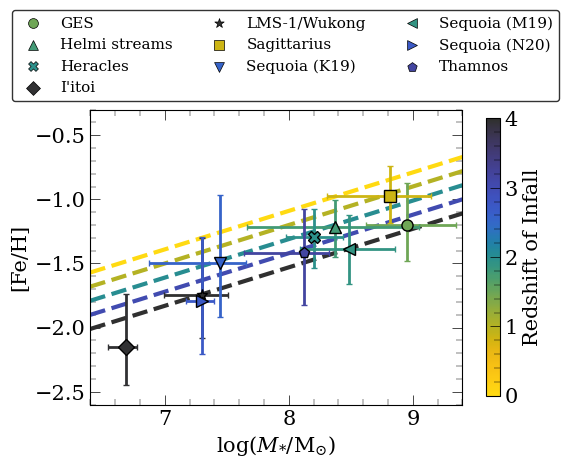

In [5]:
# Bin by stellar mass
n_bins = 20
bins = np.logspace(6.4, 9.4, n_bins)


fig, ax = plt.subplots(figsize=(6, 6))
# Plot Naidu MZR
def naidu_FeH(logM):
    return -2.11 + 0.36*(logM-6)

def ma_FeH(logM, z):
    return  -0.2+0.4*(logM-10) + 0.67*np.exp(-0.5*z) - 1.04

def kirby_FeH(logM):
    return -1.69 + 0.3*(logM-6)

def norm_evolution(z):
    return z*(-0.11)

def obs_FeH(logM, z):
    return norm_evolution(z)+kirby_FeH(logM)
    

x = np.linspace(6.4,9.4,100)


for z in [0,1,2,3,4]:
    ax.plot(x,
            obs_FeH(x,z),
            ls="--",
            color=sm.to_rgba(z),
            lw=3,)
    
z_colors = []
for substructure in substructures:

    if substructure=="Arjuna":
        continue

    # Read data from observations
    substructure_flag = f"{substructure}_flag"
    df_sub = df[df[substructure_flag]==1]

    # Get estimate of infall time and stellar mass from GalactiKit
    samples = pickle.load(open(f"{posterior_samples_dir}{substructure}.pkl", "rb"))
    
    t_acc = np.percentile(samples[:, 0], 50)
    
    z_acc = z_at_value(Planck15.lookback_time, t_acc*u.Gyr)

    median_obs = np.percentile(df_sub["FeH"].values,50)
    obs_16 = np.percentile(df_sub["FeH"].values,16)
    obs_84 = np.percentile(df_sub["FeH"].values,84)

    median_mass = np.percentile(samples[:, 1], 50)
    mass_16 = np.percentile(samples[:, 1], 16)
    mass_84 = np.percentile(samples[:, 1], 84)

    
    ax.errorbar(median_mass,
                median_obs,
                [[median_mass-mass_16],[mass_84-median_mass]],
                [[median_obs-obs_16],[obs_84-median_obs]],
                markersize=8,
                markeredgecolor='k',
                markeredgewidth=1,
                marker=substructure_markers[substructure],
                capsize=2,
                linewidth=2,
                #label=substructure_labels[substructure],
                color=sm.to_rgba(z_acc)
                )
    
    z_colors.append(sm.to_rgba(z_acc))
    
ax.set_xlabel("$\log(M_{*}/\mathrm{M}_{\odot})$")
ax.set_ylabel('[Fe/H]')

ax.set_ylim([-2.6,-0.3])
ax.set_xlim([6.4,9.4])

ax.set_aspect((3/2.9)*1)

cbar = fig.colorbar(sm,ax=ax, shrink=0.6)
cbar.set_label("Redshift of Infall")


handles = []
i=0
for substructure, color in colors_dict.items():
    if substructure=="Arjuna":
        continue
    if "Sequoia" in substructure:
        label = f"Sequoia ({substructure_labels[substructure]})"
    else:
        label = substructure_labels[substructure]
        
    line = plt.scatter([],[], 
                   s=50,
                   marker=substructure_markers[substructure],
                   edgecolor="k",
                   linewidth=0.5,
                   color=z_colors[i],
                   label=label) 
    handles.append(line)
    i += 1


fig.legend(handles=handles,
           loc="upper center", 
           bbox_to_anchor=(0.45, 0.92), 
           ncols=3, 
           frameon=True, 
           edgecolor='black', 
           fontsize=11)

fig.savefig(f"{output_dir}MZR_obs.pdf",dpi=400)


### MW accreted stellar mass 

In [6]:
def get_redshift(t):
    return z_at_value(Planck15.lookback_time, t * u.Gyr).value

rng = np.random.default_rng(15)

# --- Setup and Data Loading ---
substructures_merger_tree = ['GES', 'Sagittarius', 'Helmi', 'Sequoia_K19', 'Iitoi', 'LMS', 'Heracles']
num_samples = 1000 
z_grid = np.linspace(0, 6, 200)[::-1] # Fine redshift grid for plotting




# Dictionary to store all 1000 samples for each substructure
all_mass_samples = np.zeros((num_samples, 200))

z_16, z_50, z_84 = [], [], []

mass_s = []

for substructure in substructures_merger_tree:
    samples = pickle.load(open(f"{posterior_samples_dir}{substructure}.pkl", "rb"))
    # Column 0: Time (Gyr), Column 1: log10(Mass)
    lookback_times = samples[:, 0]
    masses = np.power(10, samples[:, 1])

    idx_samples = rng.choice(np.arange(len(masses)), size=1000, replace=False)
    
    # Convert lookback time to redshift for each of the 1000 samples
    # Note: Using a vectorized approach or a pre-computed interpolation for speed is better
    z_samples = np.vectorize(get_redshift)(np.clip(lookback_times[idx_samples],0.01,13.3))
    m_samples = masses[idx_samples]

    idx = np.argmin((z_samples-z_grid[:,None])**2,axis=0)

    for i in range(num_samples):
        all_mass_samples[i,idx[i]] += m_samples[i]

    mass_s.append(m_samples)
    z_16.append(np.percentile(z_samples,16))
    z_84.append(np.percentile(z_samples,84))
    z_50.append(np.percentile(z_samples,50))


cdf = np.cumsum(all_mass_samples, axis=1)

# calculate the median and 16th/84th percentiles at each redshift
median_cdf = np.percentile(cdf, 50, axis=0)
p16_cdf = np.percentile(cdf, 16, axis=0)
p84_cdf = np.percentile(cdf, 84, axis=0)

# Repeat excluding Sagittarius and Heracles
all_mass_samples = np.zeros((num_samples, 200))
mass_s = []

for substructure in substructures_merger_tree:
    if substructure in ["Sagittarius", "Heracles"]:
        continue
    samples = pickle.load(open(f"{posterior_samples_dir}{substructure}.pkl", "rb"))
    # Column 0: Time (Gyr), Column 1: log10(Mass)
    lookback_times = samples[:, 0]
    masses = np.power(10, samples[:, 1])

    idx_samples = rng.choice(np.arange(len(masses)), size=1000, replace=False)
    
    # Convert lookback time to redshift for each of the 1000 samples
    # Note: Using a vectorized approach or a pre-computed interpolation for speed is better
    z_samples = np.vectorize(get_redshift)(np.clip(lookback_times[idx_samples],0.01,13.3))
    m_samples = masses[idx_samples]

    idx = np.argmin((z_samples-z_grid[:,None])**2,axis=0)

    for i in range(num_samples):
        all_mass_samples[i,idx[i]] += m_samples[i]

    mass_s.append(m_samples)

cdf_2 = np.cumsum(all_mass_samples, axis=1)

# calculate the median and 16th/84th percentiles at each redshift
median_cdf_2 = np.percentile(cdf_2, 50, axis=0)
p16_cdf_2 = np.percentile(cdf_2, 16, axis=0)
p84_cdf_2 = np.percentile(cdf_2, 84, axis=0)

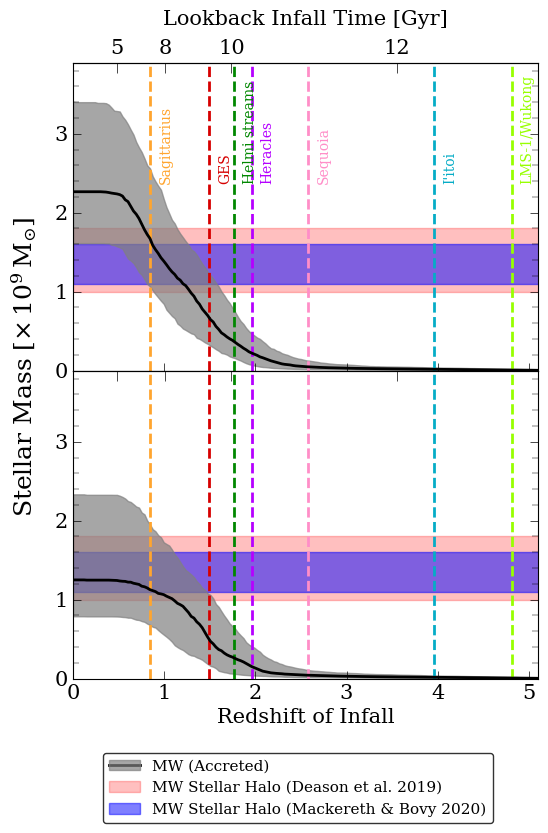

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.legend_handler import HandlerTuple
from matplotlib.ticker import NullLocator # For removing minor ticks

# 1. Initialize vertical stack
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0)

xlim = [0., 5.1]
ylim = [0., 3.9]

for o,ax in enumerate(axs):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # STRICTLY REMOVE MINOR TICKS
    ax.xaxis.set_minor_locator(NullLocator())
    
    # Configure major ticks
    # top=False prevents the bottom plot from drawing ticks onto the top plot
    ax.tick_params(which='major', direction='in', top=False, right=True, length=6)
    
    # Reference fills
    deason = ax.fill_between([0, 14], 1, 1.8, alpha=0.25, color="r")
    mackereth = ax.fill_between([0, 14], 1.1, 1.6, alpha=0.5, color="b")

    # Substructure indicators
    for i, substructure in enumerate(substructures_merger_tree):
        label = "Sequoia" if substructure == "Sequoia_K19" else substructure_labels[substructure]
        ax.axvline(z_50[i], ls='--', lw=2, c=colors_dict[substructure])
        if o==0:
            ax.text(z_50[i]+0.1, 2.4, label, rotation=90, 
                    color=colors_dict[substructure], fontsize=10)
        
    # Secondary X-axis logic
    def redshift_to_lookback(z):
        return (13.78 - Planck15.age(z).value)

    secax = ax.secondary_xaxis('top')
    # Ensure secondary axis also has no minor ticks
    secax.xaxis.set_minor_locator(NullLocator())
    
    z_range = np.linspace(0, 4, 100)
    time_range = np.array([redshift_to_lookback(z) for z in z_range])
    
    idx_list = []
    for time in [5, 8, 10, 12]:
        idx = np.argmin((time_range-time)**2)
        idx_list.append(idx)
    
    x_ticks = [z_range[idx] for idx in idx_list]
    secax.set_xticks(x_ticks)
    secax.set_xticklabels(['5', '8', '10', '12'])
    
    # Only show secondary labels on the very top plot
    if ax == axs[0]:
        secax.set_xlabel('Lookback Infall Time [Gyr]', labelpad=10)
    else:
        secax.set_xticklabels([])
        secax.set_xlabel('')

# Bottom X-axis label
axs[1].set_xlabel("Redshift of Infall")
fig.supylabel("Stellar Mass $[\\times \, 10^{9} \, \mathrm{M}_{\odot}]$")

# --- Plotting Data ---
mw_line1, = axs[0].plot(z_grid, median_cdf*1e-9, lw=2, c="k", zorder=50)
axs[0].fill_between(z_grid, p16_cdf*1e-9, p84_cdf*1e-9, color='grey', alpha=0.7)

mw_line2, = axs[1].plot(z_grid, median_cdf_2*1e-9, lw=2, c="k", zorder=50)
axs[1].fill_between(z_grid, p16_cdf_2*1e-9, p84_cdf_2*1e-9, color='grey', alpha=0.7)

# --- Legend ---
fig.legend(
    handles=[(mw_line1, axs[0].collections[2]), deason, mackereth], # Adjusted handle for fill_between
    labels=["MW (Accreted)", "MW Stellar Halo (Deason et al. 2019)", "MW Stellar Halo (Mackereth & Bovy 2020)"],
    loc="lower center",
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
    edgecolor='black',
    handler_map={tuple: HandlerTuple(ndivide=1)} 
)

#plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(f"{output_dir}Cumulative_accreted_stellar_mass_vertical.pdf", dpi=400, bbox_inches='tight')

### MW halo mass assembly across cosmic time

Substructure: GES  |  z=1.48
Substructure: Sagittarius  |  z=0.84
Substructure: Helmi  |  z=1.77
Substructure: Sequoia_K19  |  z=2.57
Substructure: Iitoi  |  z=3.96
Substructure: LMS  |  z=4.81
Substructure: Heracles  |  z=1.96


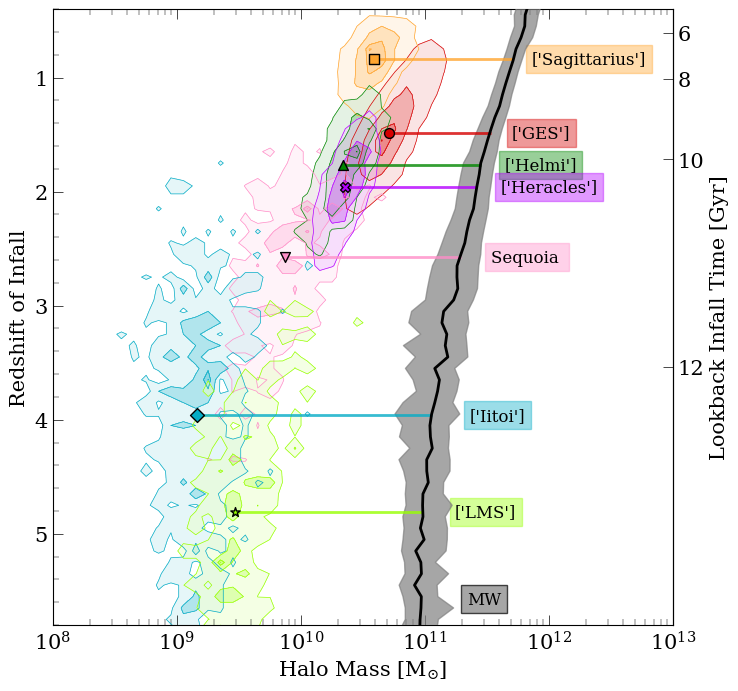

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from astropy.cosmology import Planck15
from astropy.cosmology import z_at_value
import astropy.units as u
import colorcet as cc
import itertools

posterior_samples_dir = "/mnt/aridata1/users/ariasant/MW-sbi/out/"
substructures_merger_tree_2 = substructures_merger_tree

# Setup bins
bins_mass = np.logspace(6, 12, 61)
bins_time = np.linspace(0, 10, 101)

bins_cmass = 0.5 * (bins_mass[1:] + bins_mass[:-1])
bins_ctime = 0.5 * (bins_time[1:] + bins_time[:-1])



# Calculate MW growth
# Add main branch evolution of the MW
M_MW_list, t_list = [], []
for substructure in substructures_merger_tree_2:

    samples = pickle.load(open(f"{posterior_samples_dir}{substructure}.pkl", "rb"))

    # log(M_MW) = log(M_prog) - log(M_prog/M_MW)
    M_MW = samples[:,2] - samples[:,3]
    t = samples[:,0]

    M_MW_list.append(M_MW)
    t_list.append(t)

M_MW = np.concatenate(M_MW_list)
t = np.concatenate(t_list)

def get_redshift(t):
    return z_at_value(Planck15.lookback_time, t * u.Gyr).value

z_MW = np.vectorize(get_redshift)(np.clip(t,0,13.3))

from scipy.stats import binned_statistic
z_bins = np.linspace(0,10,101)
M_MW_median, bin_edges, _ = binned_statistic(z_MW, M_MW, statistic="median", bins=z_bins)
M_MW_16, bin_edges, _ = binned_statistic(z_MW, M_MW, statistic=lambda x: np.percentile(x,16), bins=z_bins)
M_MW_84, bin_edges, _ = binned_statistic(z_MW, M_MW, statistic=lambda x: np.percentile(x,84), bins=z_bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])


# Create the full bin centers
X, Y = np.meshgrid(bins_cmass,bins_ctime)

def get_cmap_from_color(color):
    """Create a colormap from a single color transitioning to white"""
    from matplotlib.colors import LinearSegmentedColormap
    c = plt.matplotlib.colors.to_rgb(color)
    cmap_dict = {'red':   [(0, 1, 1), (1, c[0], c[0])],
                 'green': [(0, 1, 1), (1, c[1], c[1])],
                 'blue':  [(0, 1, 1), (1, c[2], c[2])]}
    return LinearSegmentedColormap('cmap', cmap_dict)

# Create figure with more space
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

for i, substructure in enumerate(substructures_merger_tree_2):

    samples = pickle.load(open(f"{posterior_samples_dir}{substructure}.pkl", "rb"))
    t = samples[:, 0]
    m = np.power(10,samples[:, 2])

    median_t = np.percentile(t,50)
    median_m = np.percentile(m,50)

    # Plot line connecting median point to MW main branch
    z_merger = z_at_value(Planck15.lookback_time, median_t * u.Gyr).value
    print(f"Substructure: {substructure}  |  z={z_merger:.2f}")
    M_MW_t = np.power(10,M_MW_median[np.argmin(np.abs(bin_centers - z_merger))])

    # Add name of the substructure
    if substructure=="Sequoia_K19":
        label = "Sequoia "
    else:
        label = [substructure]

    """ax.text(median_m, z_merger-0.05,
            label,
            color="k",#colors_dict[substructure],
            fontsize=12,
            ha='center',
            va='bottom',
            bbox=dict(facecolor=colors_dict[substructure], alpha=0.4))"""
    text_x = 1.2*np.power(10,M_MW_84[np.argmin(np.abs(bin_centers - z_merger))]) 
    ax.text(text_x, z_merger,
            label,
            color="k",
            fontsize=12,
            ha='left',    # Align left edge of box to the line end
            va='center',  # Center vertically on the line
            bbox=dict(facecolor=colors_dict[substructure], alpha=0.4, edgecolor=colors_dict[substructure]))


    ax.hlines(y=z_merger, 
              xmin=median_m, 
              xmax=M_MW_t, 
              colors=colors_dict[substructure],
              zorder=100,
              alpha=0.8,
              lw=2)
    
    # Add merger marker
    ax.scatter(median_m, z_merger, 
               s=50,
               marker=substructure_markers[substructure],
               color=colors_dict[substructure],
               edgecolor='k',
               zorder=100)
    
    z_merger_samples = np.vectorize(get_redshift)(np.clip(t,0,13.3))
    counts, xedges, yedges = np.histogram2d(m,z_merger_samples, bins=(bins_mass, bins_time))
    # Get maximum count excluding nans
    counts /= np.nanmax(counts)
    
    # Get colormap for this substructure
    cmap = get_cmap_from_color(colors_dict[substructure])
    
    
    # Plot contours
    ax.contourf(X,Y, counts.T,
                levels=[.16, .50, .84, .99],
                cmap=cmap,
                alpha=0.5)
    ax.contour(X,Y, counts.T,
                levels=[.16, .50, .84, .99],
                colors=[colors_dict[substructure]],
                alpha=1., linewidths=0.5)


# Plot shaded region for 16-84 percentile
ax.fill_betweenx(bin_centers,
                 np.power(10,M_MW_16),
                 np.power(10,M_MW_84),
                 color="grey",
                 alpha=0.7,
                 zorder=50)

ax.plot(np.power(10,M_MW_median), bin_centers, c="k", lw=2, zorder=100)


ax.set_ylim([0.4,5.8])
ax.set_xlim([1e8,10**13])
ax.set_xscale("log")
ax.invert_yaxis()
ax.set_ylabel("Redshift of Infall")
ax.set_xlabel("Halo Mass $[\\mathrm{M}_{\odot}]$")

# Add text for MW main branch
ax.text(3e11, 5.5,
        "MW",
        color="k",
        fontsize=12,
        ha='center',
        va='top',
        bbox=dict(facecolor="grey", alpha=0.7, edgecolor="k"))

# Change color of background so that light colors are more visible
#ax.set_facecolor("#e1e7b4")

# Add top axis with lookback time
def redshift_to_lookback(z):
    return (13.78 - Planck15.age(z).value)
ax.tick_params(which='both', right=False)
secax = ax.secondary_yaxis('right')
secax.tick_params(which='both', left=False, right=False)

z_range = np.linspace(0,5,100)
time_range = np.array([redshift_to_lookback(z) for z in z_range
])
idx_list = []
for time in [4,6,8,10,12]:
    idx = np.argmin((time_range-time)**2)
    idx_list.append(idx)
y_ticks = [z_range[idx] for idx in idx_list]
secax.set_yticks(y_ticks)
secax.set_yticklabels(['4','6','8','10','12'])
secax.set_ylabel('Lookback Infall Time [Gyr]')
secax.tick_params(labelright=True, labelbottom=False, direction='in')
secax.tick_params(which='major', left=False, right=True)

fig.savefig(f"{output_dir}Merger_tree_MW.pdf", dpi=400)
